# Análise de ações de petrolíferas durante a guerra EUA-Irã (2026)

Em 28 de fevereiro de 2026, os Estados Unidos e Israel iniciaram uma série de ataques contra o Irã. O conflito resultou no fechamento do Estreito de Ormuz — rota por onde passa cerca de 20% do petróleo global — e provocou uma das maiores disrupções de oferta da história do mercado de petróleo. O Brent subiu de ~\$72/barril para quase \$120 no pico.

O objetivo dessa análise é medir como as ações de empresas petrolíferas de diferentes segmentos da cadeia de valor reagiram a esse choque. A hipótese central é que **produtoras de petróleo** (que vendem um produto mais caro) se beneficiaram, enquanto **refinarias** (que compram insumo mais caro) foram prejudicadas.

**Segmentos analisados:**
- **Supermajors (Big Oil):** empresas integradas verticalmente (ExxonMobil, Chevron, Shell, BP, TotalEnergies, ConocoPhillips, Equinor)
- **Independentes (upstream):** produtoras puras (Occidental, Devon, Diamondback, EOG, Marathon Oil, APA, Coterra, Hess)
- **Refino (downstream):** Valero, Marathon Petroleum, Phillips 66
- **Estatais/emergentes:** Petrobras, Suncor, Canadian Natural Resources, Ecopetrol, YPF
- **ETFs:** XLE, OIH, USO, BNO (benchmarks setoriais)

**Estrutura da análise:**
1. Comportamento dos preços
2. Retornos normalizados e comparação entre segmentos
3. Correlação e rolling correlation
4. Volatilidade
5. Volume de negociação
6. Drawdown
7. Hipóteses testáveis nos dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import numpy as np

In [2]:
# Lista de tickers de empresas relacionadas com petróleo em diferentes setores

# === SUPERMAJORS (integradas globais) ===
supermajors = [
    "XOM",   # ExxonMobil
    "CVX",   # Chevron
    "SHEL",  # Shell
    "BP",    # BP
    "TTE",   # TotalEnergies
    "COP",   # ConocoPhillips
    "EQNR",  # Equinor (estatal norueguesa)
]
 
# === PRODUTORAS INDEPENDENTES (upstream) ===
independentes = [
    "OXY",   # Occidental Petroleum
    "DVN",   # Devon Energy
    "FANG",  # Diamondback Energy
    "EOG",   # EOG Resources
    "APA",   # APA Corporation
    "CTRA"  # Coterra Energy
]
 
# === SERVIÇOS E EQUIPAMENTOS (oil services) ===
services = [
    "SLB",   # Schlumberger
    "HAL",   # Halliburton
    "BKR",   # Baker Hughes
]
 
# === DOWNSTREAM / REFINO ===
refino = [
    "VLO",   # Valero Energy
    "MPC",   # Marathon Petroleum
    "PSX",   # Phillips 66
]
 
# === ESTATAIS / EMERGENTES ===
estatais = [
    "PBR",   # Petrobras (ON)
    "SU",    # Suncor Energy
    "CNQ",   # Canadian Natural Resources
    "EC",    # Ecopetrol
    "YPF",   # YPF
]
 
# === ETFs (benchmarks setoriais) ===
etfs = [
    "XLE",   # Energy Select Sector SPDR
    "OIH",   # VanEck Oil Services ETF
    "USO",   # United States Oil Fund (WTI)
    "BNO",   # United States Brent Oil Fund
]

# Preço do Brent como referência
brent = ["BZ=F"]

# Todos os tickers de ações (sem ETFs)
all_stocks = supermajors + independentes + services + refino + estatais
all_tickers = all_stocks + etfs + brent

# Mapa ticker -> categoria
categorias = {
    "supermajor":   supermajors,
    "independente":  independentes,
    "services":      services,
    "refino":        refino,
    "estatal":       estatais,
    "etf":           etfs,
}

ticker_categoria = {
    ticker: cat
    for cat, tickers in categorias.items()
    for ticker in tickers
}

START = '2025-06-01'
END = '2026-04-25'
EVENTO = pd.Timestamp('2026-02-28')

In [3]:
# Download de todos os dados de uma vez

data_all = yf.download(all_tickers, start=START, end=END).dropna()
df_close = data_all['Close']
df_volume = data_all['Volume']

# tinham apenas dois valores NaN e eles foram tirados 

[*********************100%***********************]  29 of 29 completed


In [4]:
df_close

Ticker,APA,BKR,BNO,BP,BZ=F,CNQ,COP,CTRA,CVX,DVN,...,PSX,SHEL,SLB,SU,TTE,USO,VLO,XLE,XOM,YPF
Date,,,,,,,,,,,,,,,,,,,,,
2025-06-02,16.637150,36.809402,27.910000,28.387388,64.629997,30.144329,84.561653,24.464668,133.510696,30.353888,...,111.294495,65.542969,32.351101,35.959625,57.981796,69.550003,125.693581,40.015327,100.544472,34.619999
2025-06-03,17.539568,37.026394,28.110001,28.368193,65.629997,30.760517,85.722038,24.815836,135.166992,31.201921,...,112.940346,65.912231,33.098267,36.224533,57.560184,69.889999,128.289734,40.490086,101.276237,35.320000
2025-06-04,17.203560,36.779812,27.809999,27.753998,64.860001,30.232355,83.810822,24.279329,133.055466,30.763287,...,109.541519,65.368065,32.525833,36.050884,56.582798,69.339996,123.969337,39.700432,99.812714,33.610001
2025-06-05,17.136360,36.641727,27.990000,27.878756,65.339996,30.310600,83.225754,24.220802,132.600220,30.626820,...,109.298058,65.620705,32.369270,36.318806,56.764862,69.930000,124.302422,39.661682,99.354134,33.880001
2025-06-06,17.760374,37.381466,28.520000,28.109081,66.470001,30.887667,85.049210,24.952400,135.806290,31.474857,...,111.304237,66.096855,33.142292,36.497425,56.841518,71.379997,125.742569,40.407726,101.734810,34.270000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,35.730839,59.169998,47.450001,45.119999,95.480003,43.299999,116.449997,31.420000,183.250000,44.939999,...,155.750000,88.000000,52.200001,61.660000,87.309998,121.320000,226.279999,55.070000,147.679993,40.980000
2026-04-21,37.349998,60.250000,50.070000,45.910000,98.480003,44.279999,120.260002,31.850000,185.979996,45.599998,...,159.380005,88.660004,52.770000,62.549999,88.370003,128.250000,233.389999,55.869999,148.360001,43.119999
2026-04-22,38.060001,62.540001,50.529999,46.369999,101.910004,44.680000,122.599998,32.930000,186.320007,47.119999,...,160.649994,89.489998,54.349998,63.430000,89.570000,129.399994,234.360001,56.540001,149.500000,43.150002


In [5]:
df_close.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 226 entries, 2025-06-02 to 2026-04-24
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   APA     226 non-null    float64
 1   BKR     226 non-null    float64
 2   BNO     226 non-null    float64
 3   BP      226 non-null    float64
 4   BZ=F    226 non-null    float64
 5   CNQ     226 non-null    float64
 6   COP     226 non-null    float64
 7   CTRA    226 non-null    float64
 8   CVX     226 non-null    float64
 9   DVN     226 non-null    float64
 10  EC      226 non-null    float64
 11  EOG     226 non-null    float64
 12  EQNR    226 non-null    float64
 13  FANG    226 non-null    float64
 14  HAL     226 non-null    float64
 15  MPC     226 non-null    float64
 16  OIH     226 non-null    float64
 17  OXY     226 non-null    float64
 18  PBR     226 non-null    float64
 19  PSX     226 non-null    float64
 20  SHEL    226 non-null    float64
 21  SLB     226 non-null    float64

In [6]:
# Separar DataFrames por setor para conveniência

df_supermajor = df_close[supermajors]
df_independente = df_close[independentes]
df_services = df_close[services]
df_refino = df_close[refino]
df_estatal = df_close[estatais]
df_etfs = df_close[etfs]
df_brent = df_close[['BZ=F']].rename(columns={'BZ=F': 'Brent'})

In [7]:
df_supermajor

Ticker,XOM,CVX,SHEL,BP,TTE,COP,EQNR
Date,,,,,,,
2025-06-02,100.544472,133.510696,65.542969,28.387388,57.981796,84.561653,23.277721
2025-06-03,101.276237,135.166992,65.912231,28.368193,57.560184,85.722038,23.229866
2025-06-04,99.812714,133.055466,65.368065,27.753998,56.582798,83.810822,23.000153
2025-06-05,99.354134,132.600220,65.620705,27.878756,56.764862,83.225754,23.191580
2025-06-06,101.734810,135.806290,66.096855,28.109081,56.841518,85.049210,23.469152
...,...,...,...,...,...,...,...
2026-04-20,147.679993,183.250000,88.000000,45.119999,87.309998,116.449997,36.009998
2026-04-21,148.360001,185.979996,88.660004,45.910000,88.370003,120.260002,37.650002
2026-04-22,149.500000,186.320007,89.489998,46.369999,89.570000,122.599998,37.970001


In [8]:
df_supermajor.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 226 entries, 2025-06-02 to 2026-04-24
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   XOM     226 non-null    float64
 1   CVX     226 non-null    float64
 2   SHEL    226 non-null    float64
 3   BP      226 non-null    float64
 4   TTE     226 non-null    float64
 5   COP     226 non-null    float64
 6   EQNR    226 non-null    float64
dtypes: float64(7)
memory usage: 14.1 KB


---
## 1. Comportamento dos preços

Nesta seção observamos os preços brutos ao longo do período. A linha vermelha tracejada marca o início do conflito (28/02/2026). Alguns eventos importantes a observar:

- **Junho/2025:** início dos dados e momento em que os EUA atacaram instalações nucleares iranianas
- **28/02/2026:** ataques EUA-Israel contra o Irã, morte do líder supremo iraniano
- **Março/2026:** Irã fecha o Estreito de Ormuz, ataques a infraestrutura energética no Golfo
- **08/04/2026:** cessar-fogo condicional anunciado
- **Abril/2026:** Estreito de Ormuz permanece efetivamente fechado, negociações em andamento

In [9]:
def add_evento(ax, label="Início do conflito"):
    """Adiciona a linha vertical do evento em qualquer Axes."""
    ax.axvline(EVENTO, color='red', linestyle='--', alpha=0.7, label=label)

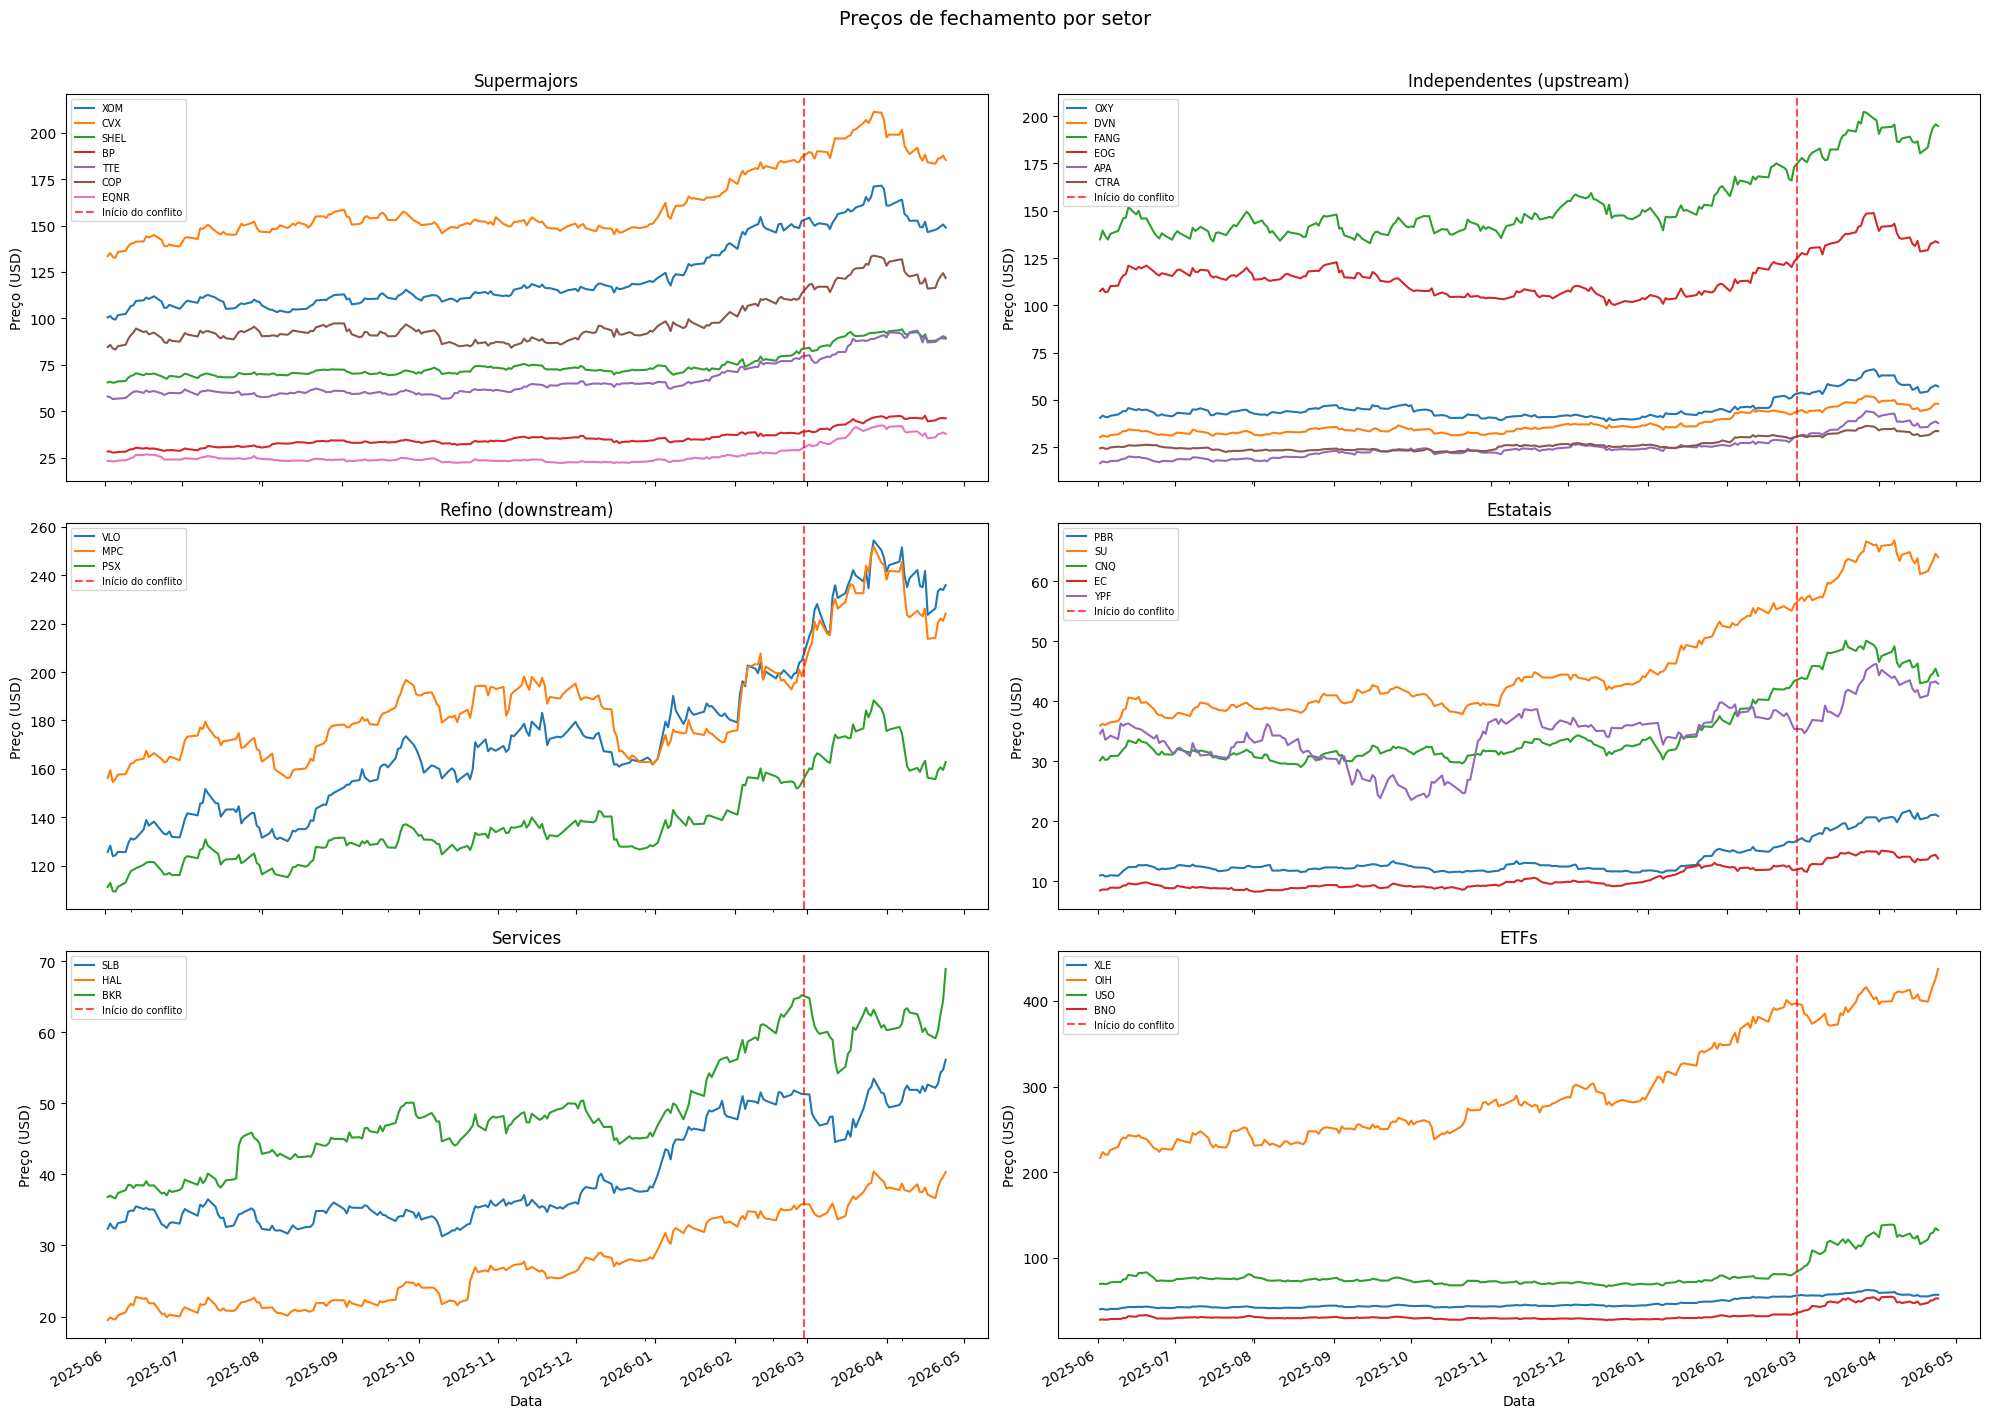

In [10]:
# Preços brutos — um gráfico por setor

setores = {
    'Supermajors': df_supermajor,
    'Independentes (upstream)': df_independente,
    'Refino (downstream)': df_refino,
    'Estatais': df_estatal,
    'Services': df_services,
    'ETFs': df_etfs
}

fig, axes = plt.subplots(3, 2, figsize=(20, 14), sharex=True)
axes = axes.flatten()

for ax, (nome, df) in zip(axes, setores.items()):
    df.plot(ax=ax)
    add_evento(ax)
    ax.set_title(nome)
    ax.set_ylabel('Preço (USD)')
    ax.set_xlabel('Data')
    ax.legend(fontsize=7)

plt.suptitle('Preços de fechamento por setor', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Retornos

Preços absolutos não são diretamente comparáveis — uma ação de \$120 e outra de \$30 podem ter desempenhos idênticos em termos percentuais. A normalização em base 100 resolve isso: todas partem do mesmo ponto e a distância vertical reflete a diferença de retorno acumulado.

Os retornos logarítmicos são usados porque são aditivos no tempo: $r_{acum} = \sum r_t$, e o retorno percentual acumulado é $e^{r_{acum}} - 1$.

In [11]:
# Log-retornos de todas as ações

log_ret = np.log(df_close / df_close.shift(1)).dropna()
log_ret.head()

Ticker,APA,BKR,BNO,BP,BZ=F,CNQ,COP,CTRA,CVX,DVN,...,PSX,SHEL,SLB,SU,TTE,USO,VLO,XLE,XOM,YPF
Date,,,,,,,,,,,,,,,,,,,,,
2025-06-03,0.052821,0.005878,0.007140,-0.000676,0.015354,0.020235,0.013629,0.014252,0.012329,0.027555,...,0.014680,0.005618,0.022833,0.007340,-0.007298,0.004877,0.020444,0.011795,0.007252,0.020018
2025-06-04,-0.019343,-0.006682,-0.010730,-0.021889,-0.011802,-0.017319,-0.022548,-0.021857,-0.015745,-0.014158,...,-0.030556,-0.008290,-0.017446,-0.004805,-0.017126,-0.007901,-0.034257,-0.019695,-0.014556,-0.049626
2025-06-05,-0.003914,-0.003761,0.006452,0.004485,0.007373,0.002585,-0.007005,-0.002413,-0.003427,-0.004446,...,-0.002225,0.003857,-0.004825,0.007404,0.003212,0.008473,0.002683,-0.000977,-0.004605,0.008001
2025-06-06,0.035767,0.019987,0.018758,0.008228,0.017146,0.018859,0.021673,0.029758,0.023891,0.027313,...,0.018189,0.007230,0.023601,0.004906,0.001350,0.020523,0.011519,0.018635,0.023679,0.011445
2025-06-09,0.007002,0.011282,0.007684,0.005787,0.008539,0.001266,0.009358,0.014361,0.003915,0.011087,...,0.015713,0.003522,0.007354,0.005423,0.005548,0.009343,-0.000701,0.001916,0.006691,-0.016476


In [12]:
# Normalização base 100

base100 = df_close / df_close.iloc[0] * 100

### 2.1 Retorno normalizado (base 100) por setor

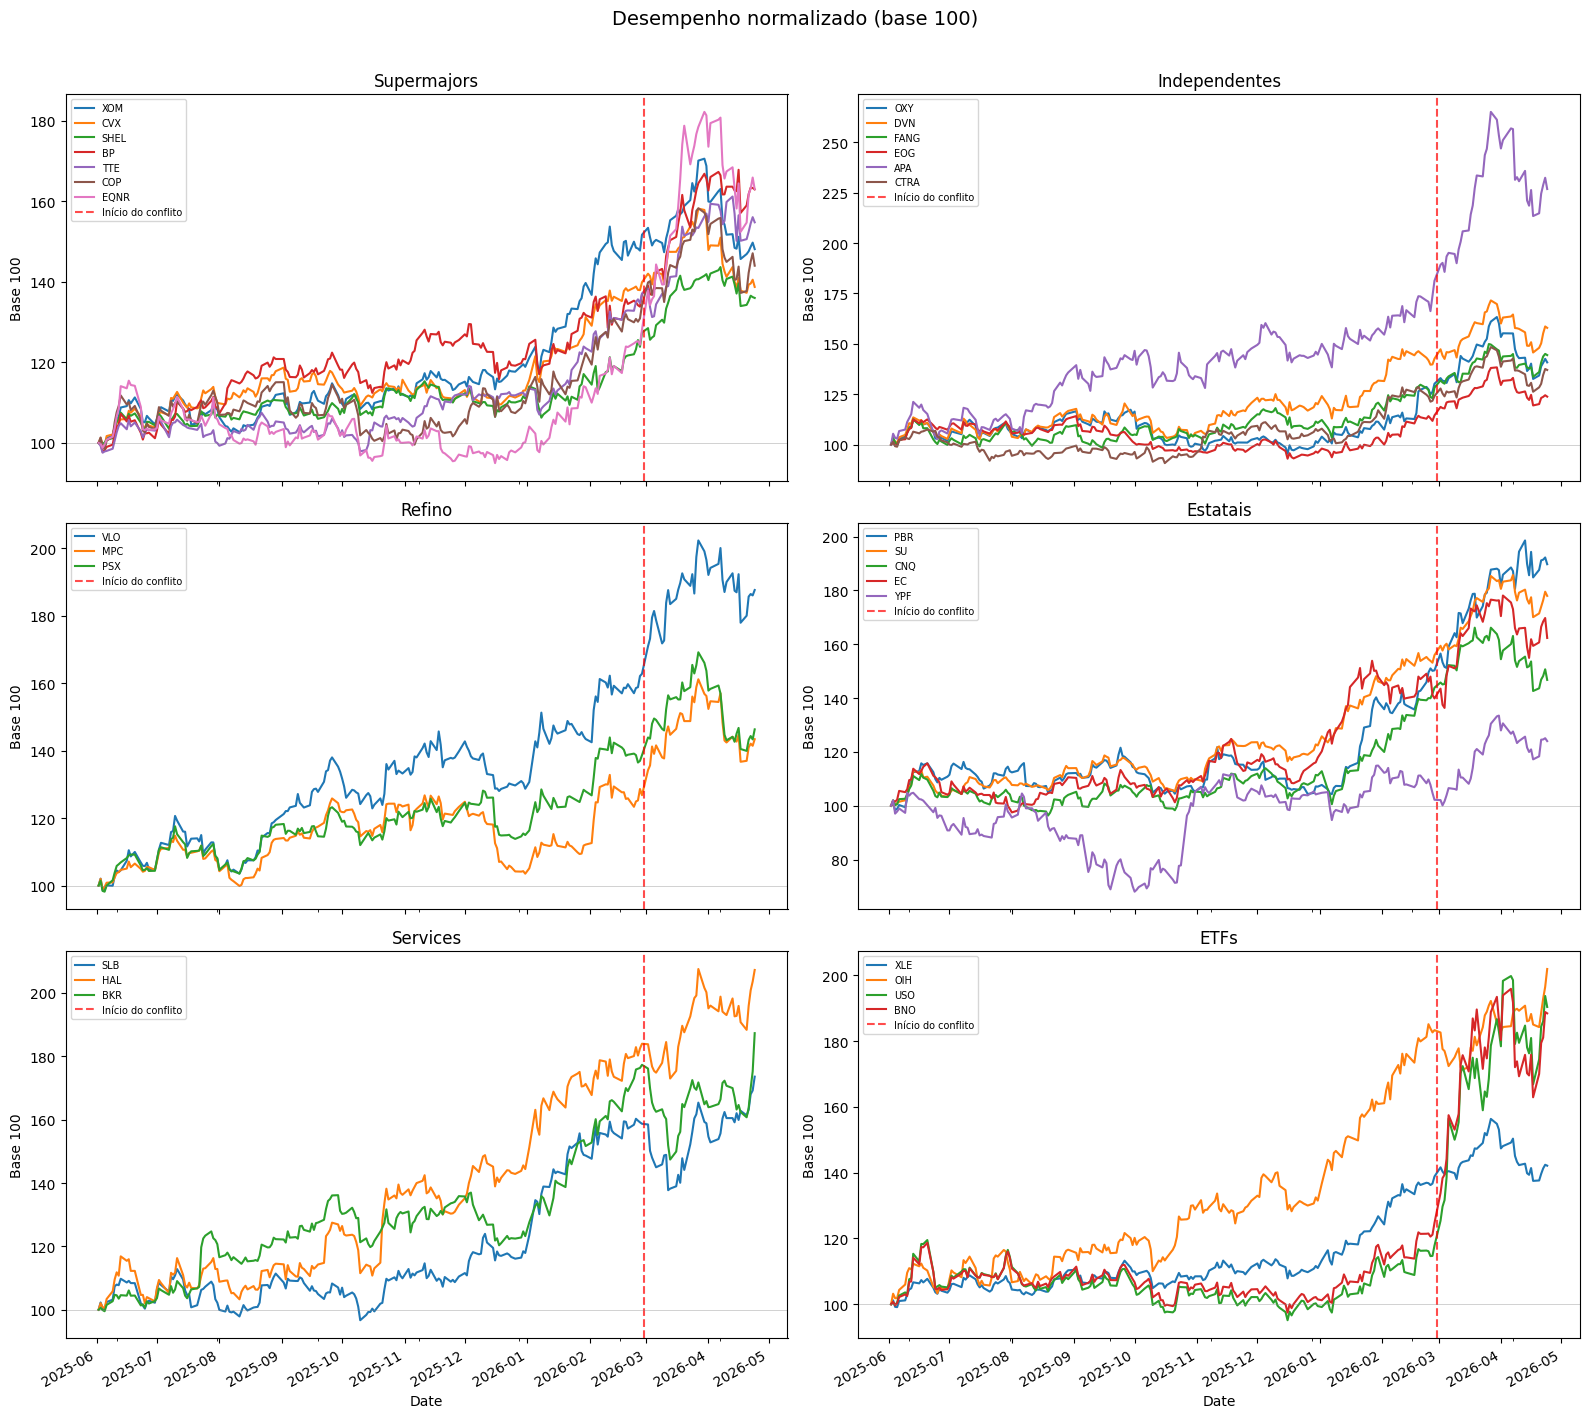

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

for ax, (nome, tickers) in zip(axes, {
    'Supermajors': supermajors,
    'Independentes': independentes,
    'Refino': refino,
    'Estatais': estatais,
    'Services': services,
    'ETFs': etfs,
}.items()):
    base100[tickers].plot(ax=ax)
    add_evento(ax)
    ax.set_title(nome)
    ax.set_ylabel('Base 100')
    ax.axhline(100, color='gray', linewidth=0.5, alpha=0.5)
    ax.legend(fontsize=7)

plt.suptitle('Desempenho normalizado (base 100)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Nota sobre ETFs: os ETFs não são setores ou empresas, são apenas uma cesta de ativos. Por esse ponto eles ficaram de fora de grande parte das análises que foram feitas.

### 2.2 Comparação entre segmentos — retorno médio por setor

Aqui testamos a hipótese central: produtoras (supermajors + independentes) vs. refinarias. As linhas individuais de cada empresa aparecem transparentes e a média do grupo em destaque.

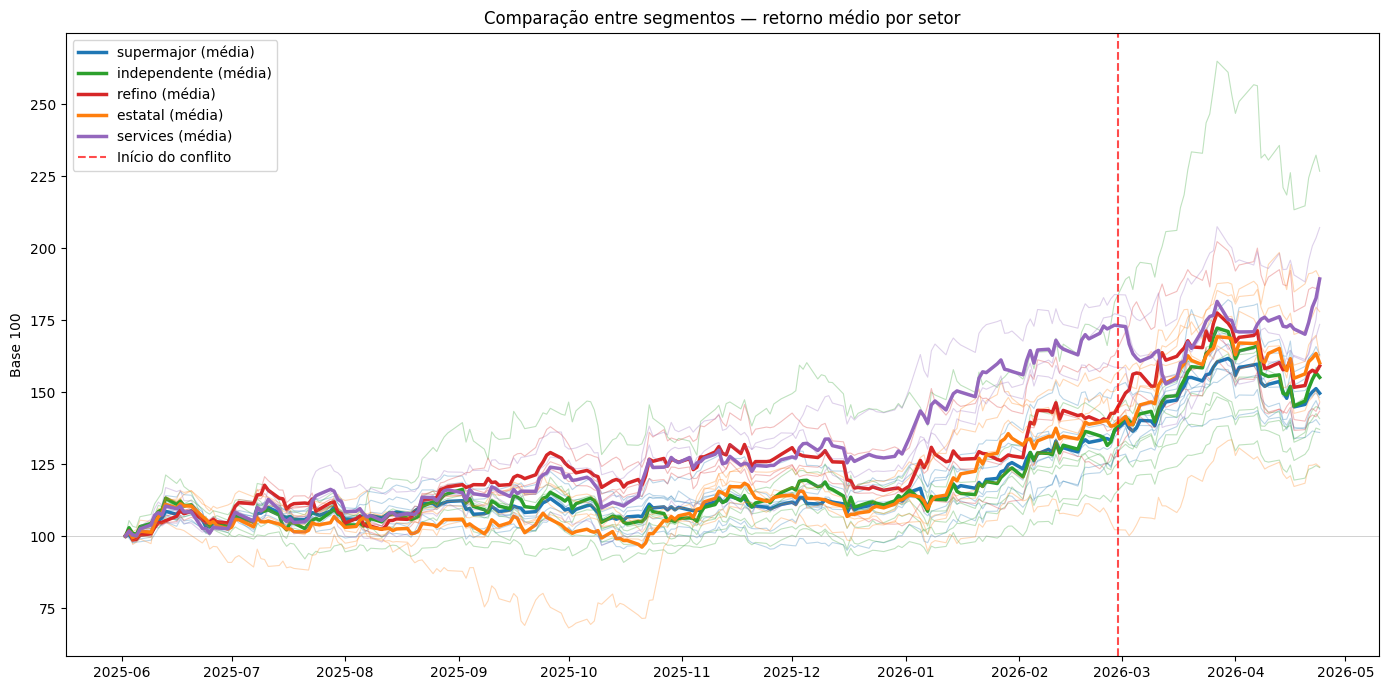

In [14]:
cores_setor = {
    'supermajor':   '#1f77b4',
    'independente':  '#2ca02c',
    'refino':        '#d62728',
    'estatal':       '#ff7f0e',
    'services':      '#9467bd',
}

fig, ax = plt.subplots(figsize=(14, 7))

for cat, cor in cores_setor.items():
    tickers = categorias[cat]
    subset = base100[tickers]
    
    # Linhas individuais (transparentes)
    for ticker in tickers:
        ax.plot(subset[ticker], color=cor, alpha=0.3, linewidth=0.8)
    
    # Média do grupo (destaque)
    media = subset.mean(axis=1)
    ax.plot(media, color=cor, linewidth=2.5, label=f'{cat} (média)')

add_evento(ax)
ax.axhline(100, color='gray', linewidth=0.5, alpha=0.5)
ax.set_ylabel('Base 100')
ax.set_title('Comparação entre segmentos — retorno médio por setor')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 2.3 Retorno médio por setor com Brent como referência

Incluímos o preço do Brent (normalizado) para ancorar a análise no fundamento: o preço da commodity em si.

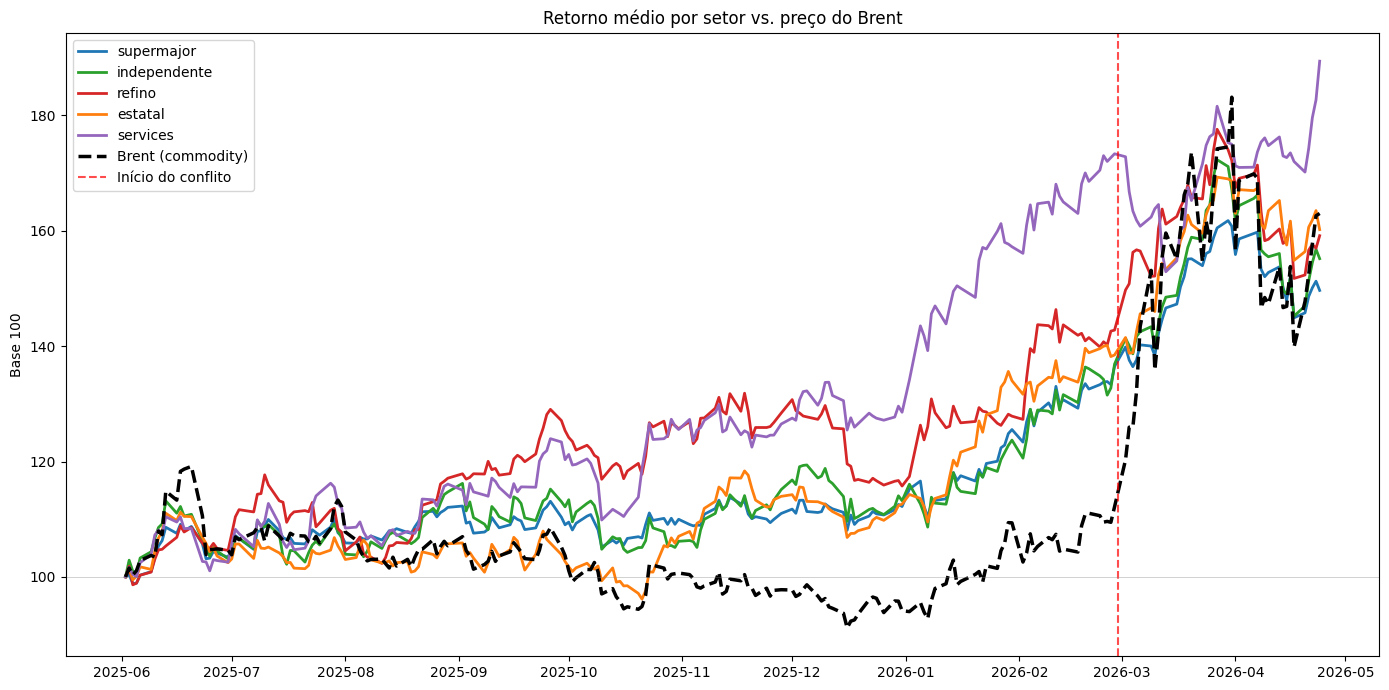

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

for cat, cor in cores_setor.items():
    tickers = categorias[cat]
    media = base100[tickers].mean(axis=1)
    ax.plot(media, color=cor, linewidth=2, label=f'{cat}')

# Brent como referência
brent_norm = df_brent / df_brent.iloc[0] * 100
ax.plot(brent_norm, color='black', linewidth=2.5, linestyle='--', label='Brent (commodity)')

add_evento(ax)
ax.axhline(100, color='gray', linewidth=0.5, alpha=0.5)
ax.set_ylabel('Base 100')
ax.set_title('Retorno médio por setor vs. preço do Brent')
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Retornos diários por ação (com eventos extremos)

Retornos diários individuais com destaque para eventos raros — retornos com magnitude maior que 3 desvios-padrão. Esses pontos vermelhos indicam dias de movimento atípico.

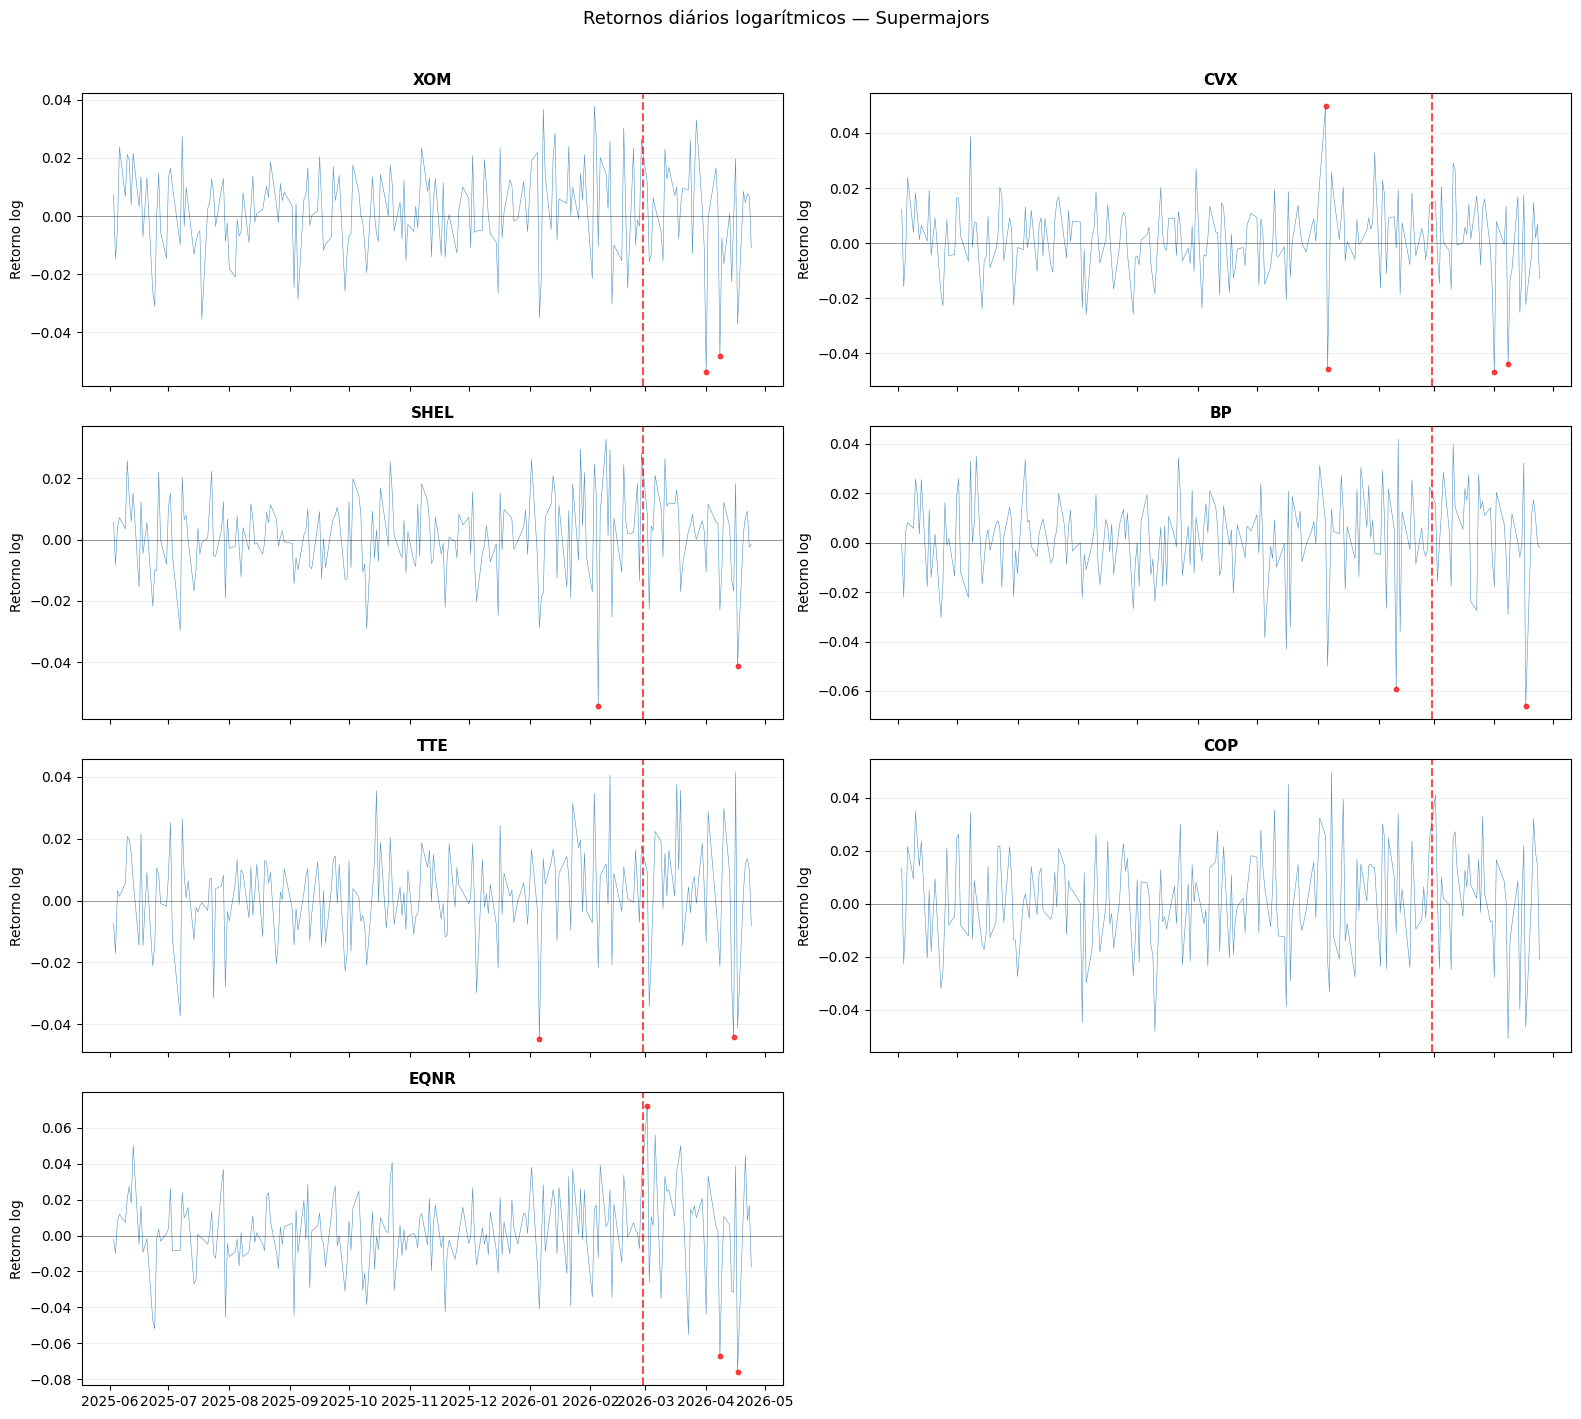

In [16]:
# Retornos diários — Supermajors

n_cols = 2
n_rows = (len(supermajors) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows), sharex=True)
axes = axes.flatten()

for ax, ticker in zip(axes, supermajors):
    serie = log_ret[ticker]
    ax.plot(serie.index, serie, linewidth=0.4, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
    add_evento(ax, label=None)
    ax.set_title(ticker, fontsize=11, fontweight='bold')
    ax.set_ylabel('Retorno log')
    ax.grid(axis='y', alpha=0.2)
    
    # Destacar retornos extremos (> 3 desvios-padrão)
    threshold = serie.std() * 3
    extremes = serie[serie.abs() > threshold]
    ax.scatter(extremes.index, extremes.values, color='red', s=10, zorder=5, alpha=0.7)

# Esconder subplot extra se número ímpar
for j in range(len(supermajors), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Retornos diários logarítmicos — Supermajors', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

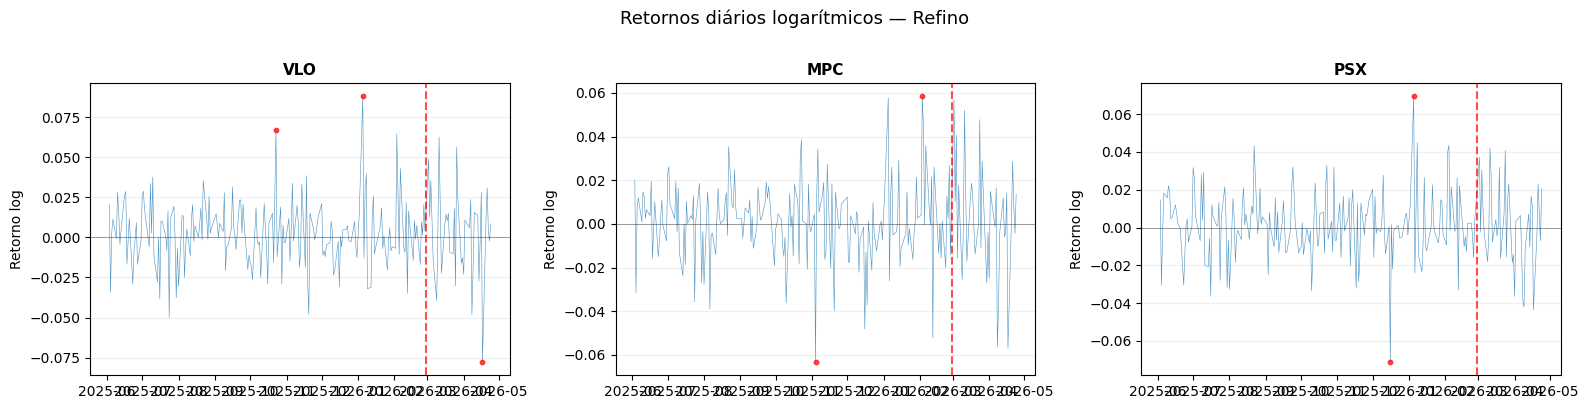

In [17]:
# Retornos diários — Refino

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for ax, ticker in zip(axes, refino):
    serie = log_ret[ticker]
    ax.plot(serie.index, serie, linewidth=0.4, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
    add_evento(ax, label=None)
    ax.set_title(ticker, fontsize=11, fontweight='bold')
    ax.set_ylabel('Retorno log')
    ax.grid(axis='y', alpha=0.2)
    
    threshold = serie.std() * 3
    extremes = serie[serie.abs() > threshold]
    ax.scatter(extremes.index, extremes.values, color='red', s=10, zorder=5, alpha=0.7)

plt.suptitle('Retornos diários logarítmicos — Refino', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Correlação

A correlação de Pearson é calculada sobre os **retornos logarítmicos**, não sobre os preços. Correlação de preços entre ativos com tendência comum (todos subiram no período) seria artificialmente alta — quase tudo daria >0.95. A correlação dos retornos captura a co-movimentação real dia a dia.

A rolling correlation mostra como essa relação evolui ao longo do tempo. A hipótese é que a correlação (já alta entre petrolíferas) aumentou ainda mais após o início do conflito, uma vez que o choque afetou todo o setor simultaneamente.

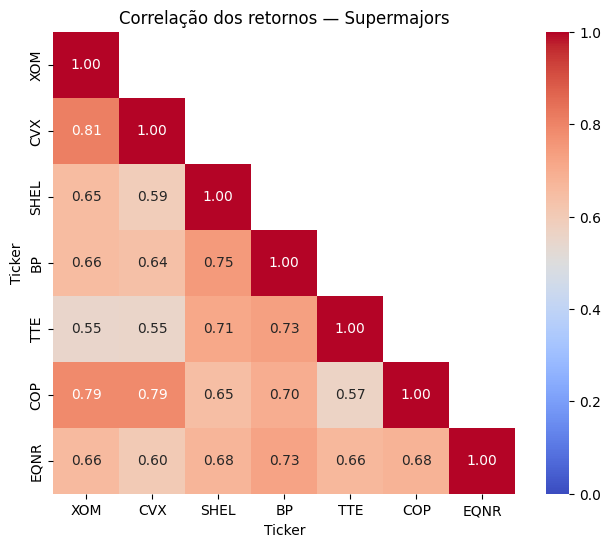

In [18]:
# Correlação sobre retornos (não sobre preços)

# Supermajors
corr_supermajor = log_ret[supermajors].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_supermajor, dtype=bool), k=1)
sns.heatmap(corr_supermajor, annot=True, cmap='coolwarm', vmin=0, vmax=1,
            fmt='.2f', square=True, mask=mask)
plt.title('Correlação dos retornos — Supermajors')
plt.show()

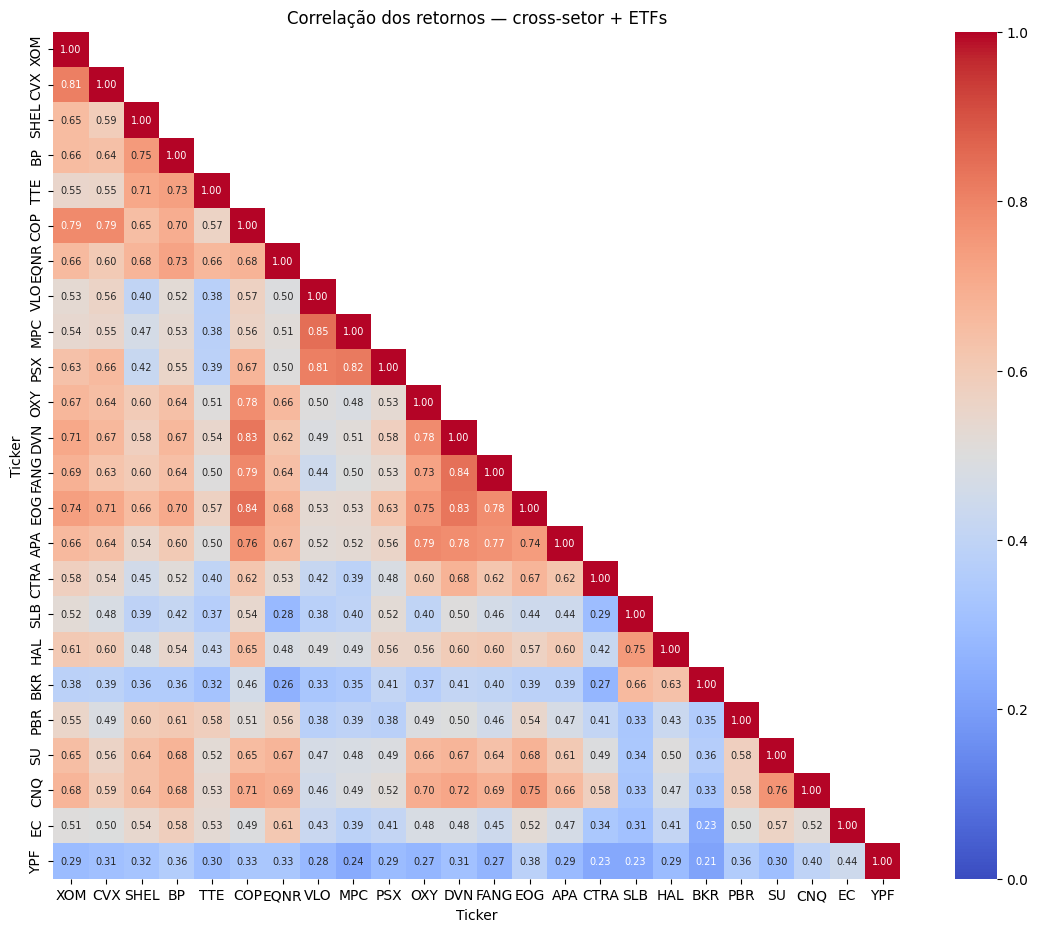

In [19]:
# Correlação cross-setor + ETFs: supermajors + refino + independentes + services + estatais

cross_sector = supermajors + refino + independentes + services + estatais
corr_cross = log_ret[cross_sector].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_cross, dtype=bool), k=1)
sns.heatmap(corr_cross, annot=True, cmap='coolwarm', vmin=0, vmax=1,
            fmt='.2f', square=True, mask=mask, annot_kws={'fontsize': 7})
plt.title('Correlação dos retornos — cross-setor + ETFs')
plt.show()

### 3.1 Rolling Correlation

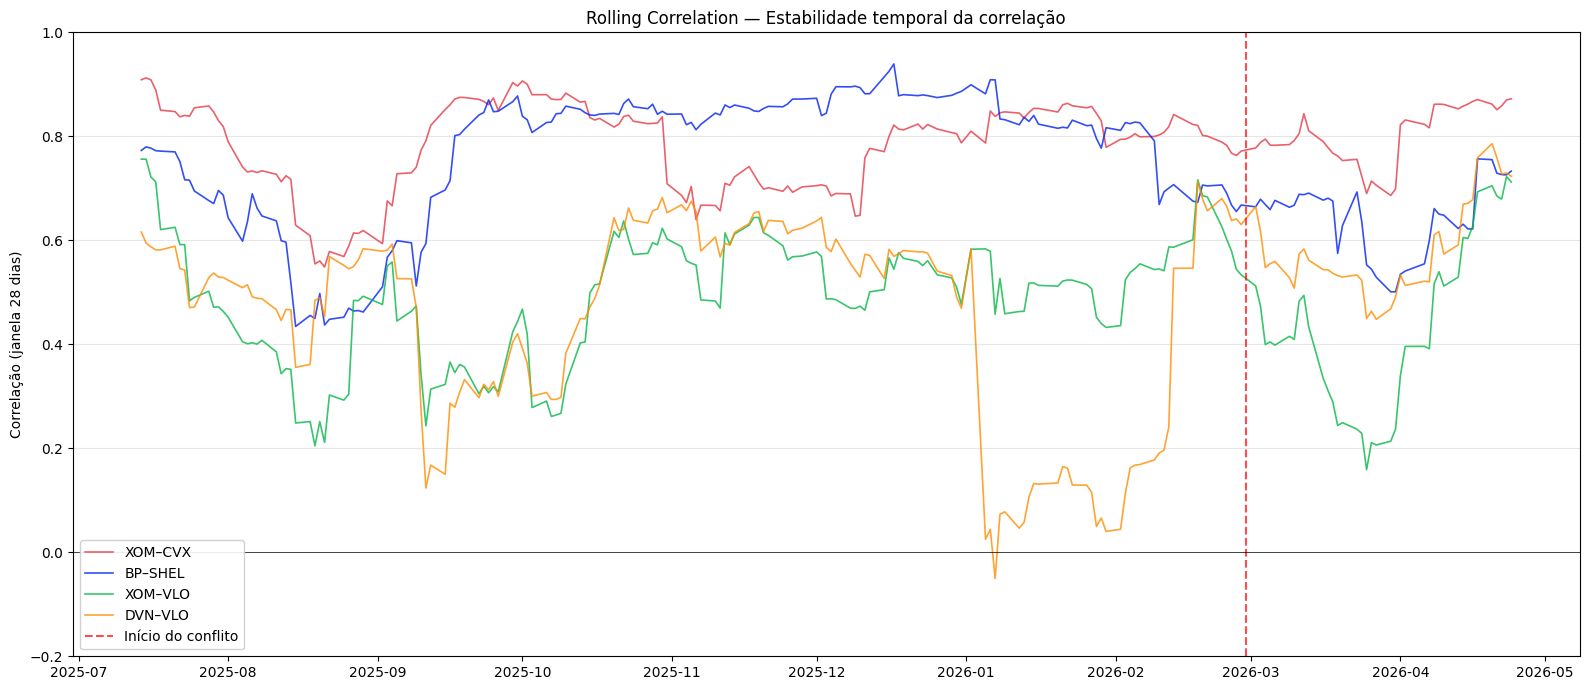

In [20]:
rolling_window = 28

# Pares intra-setor e inter-setor
pairs = [
    ('XOM', 'CVX'),    # supermajor-supermajor
    ('BP', 'SHEL'),    # supermajor-supermajor (europeias)
    ('XOM', 'VLO'),    # supermajor vs refino
    ('DVN', 'VLO'),    # independente vs refino
]

pair_colors = ['#E63946', '#0122F3', '#06B747', '#FF8C00']

fig, ax = plt.subplots(figsize=(16, 7))

for (t1, t2), color in zip(pairs, pair_colors):
    rolling_corr = log_ret[t1].rolling(rolling_window).corr(log_ret[t2])
    ax.plot(rolling_corr.index, rolling_corr, label=f'{t1}–{t2}',
            linewidth=1.2, alpha=0.8, color=color)

add_evento(ax, label='Início do conflito')
ax.set_ylabel(f'Correlação (janela {rolling_window} dias)')
ax.set_title('Rolling Correlation — Estabilidade temporal da correlação')
ax.legend(loc='lower left', framealpha=0.9)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.2, 1.0)
plt.tight_layout()
plt.show()

É interessante notar que o início do conflito não aumentou a correlação entre os retornos das empresas. Isso não era esperado, pois em momentos de crise a correlação entre empresas tende a subir bastante, mesmo em casos como esse em que a correlação já é alta.

---
## 4. Volatilidade

A volatilidade é calculada como o desvio-padrão rolante dos retornos diários (janela de 21 dias úteis ≈ 1 mês). Essa medida captura a formação de clusters de volatilidade — períodos em que o mercado se torna mais instável.

A expectativa é que a volatilidade aumente significativamente a partir de 28/02/2026 para todos os setores, mas possivelmente mais para refinarias (incerteza sobre repasse de custos) do que para produtoras (benefício mais direto).

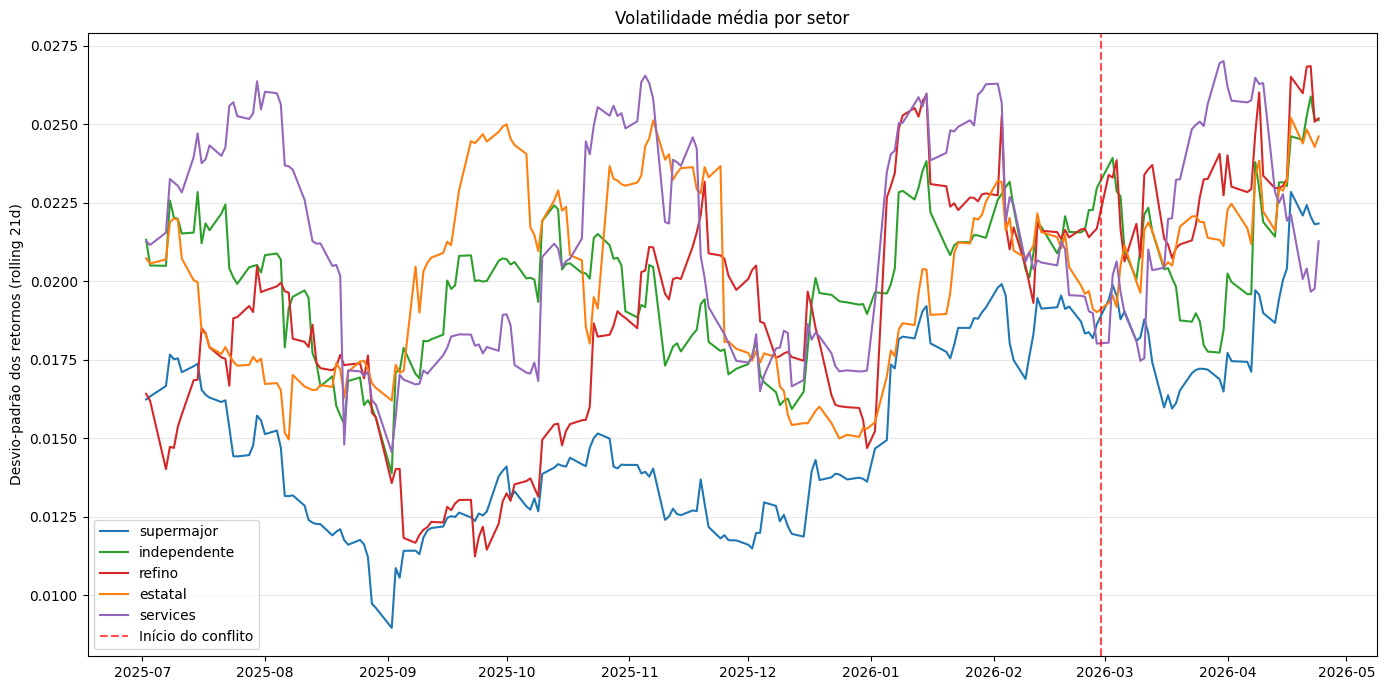

In [21]:
vol_window = 21  # ~1 mês de dias úteis

fig, ax = plt.subplots(figsize=(14, 7))

for cat, cor in cores_setor.items():
    tickers = categorias[cat]
    # Volatilidade média do setor
    vol_setor = log_ret[tickers].rolling(vol_window).std().mean(axis=1)
    ax.plot(vol_setor, color=cor, linewidth=1.5, label=cat)

add_evento(ax)
ax.set_ylabel('Desvio-padrão dos retornos (rolling 21d)')
ax.set_title('Volatilidade média por setor')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

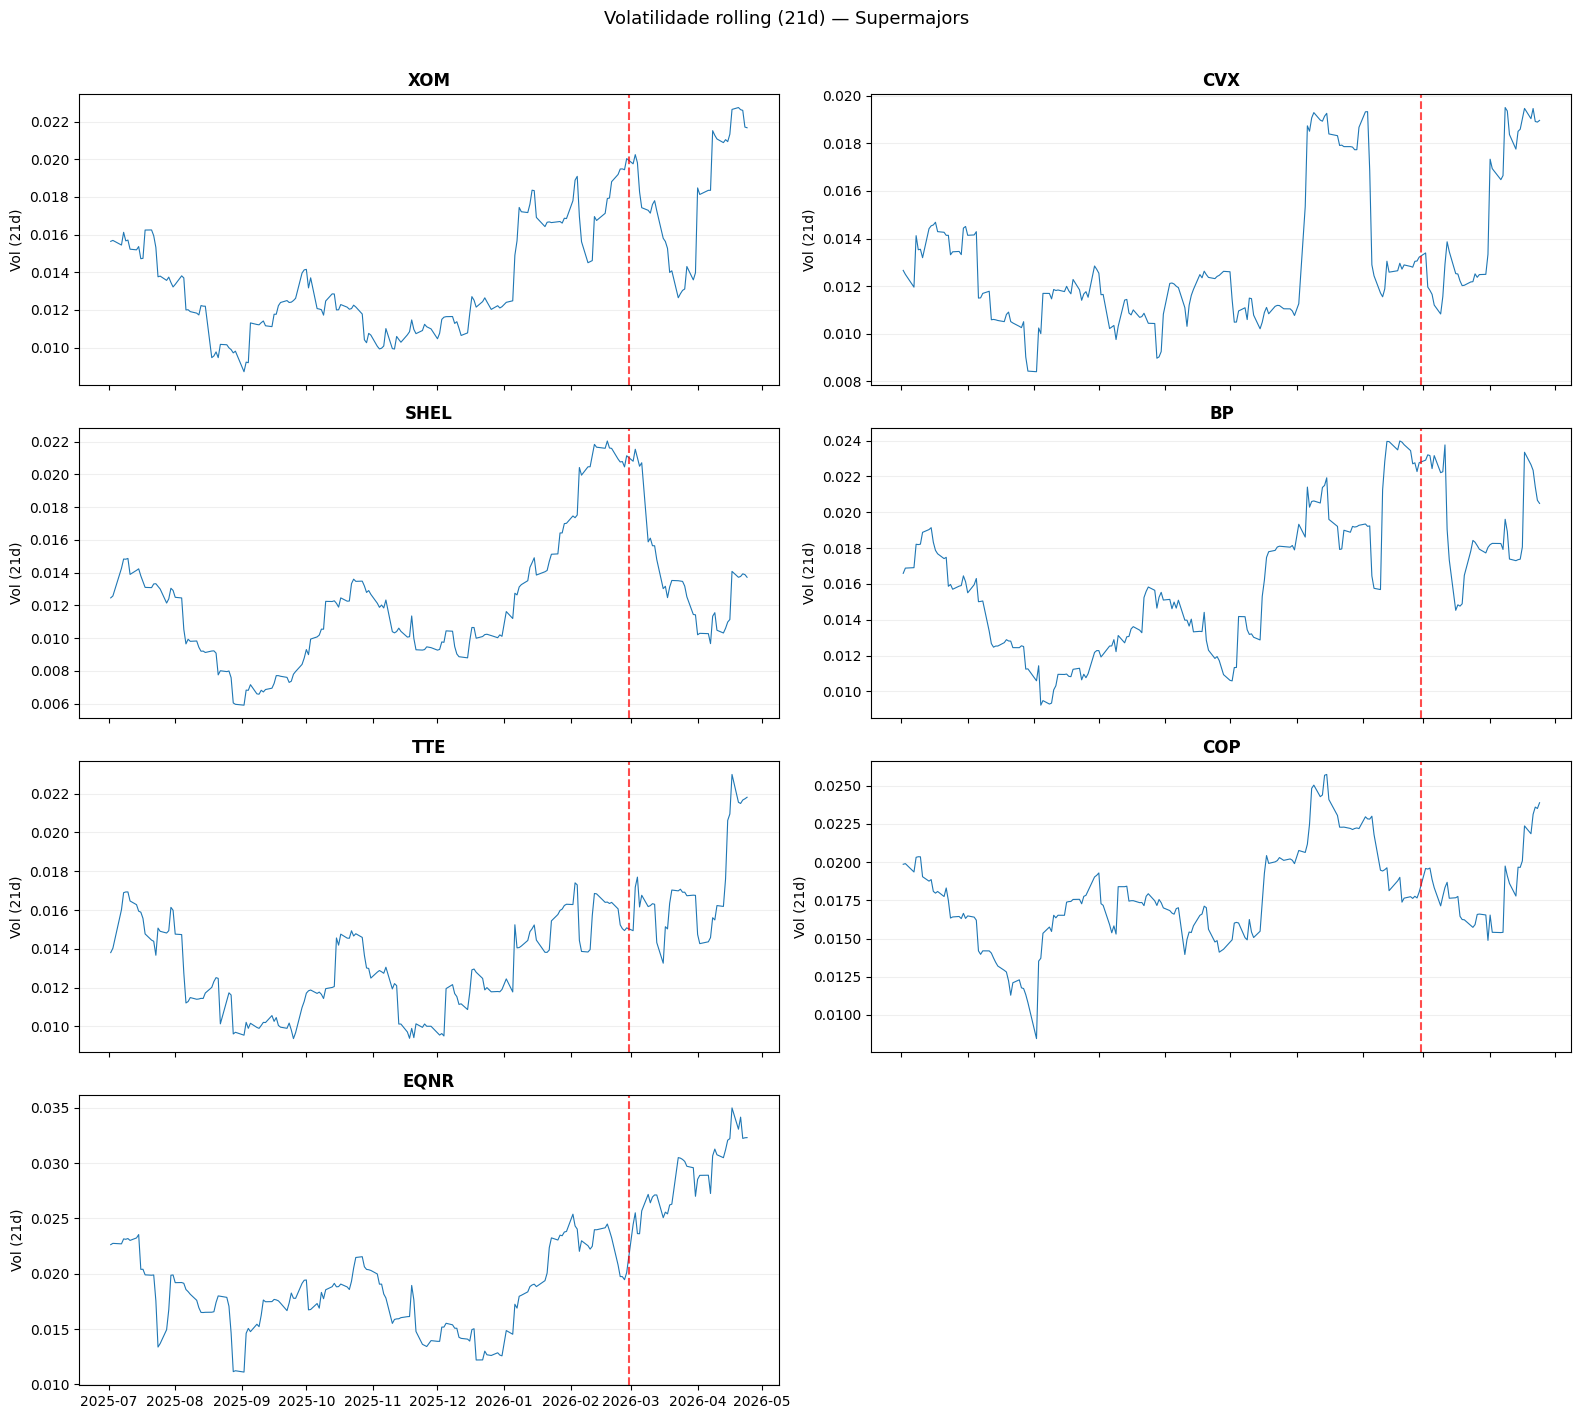

In [22]:
# Volatilidade individual — Supermajors

n_rows = (len(supermajors) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 3.5 * n_rows), sharex=True)
axes = axes.flatten()

for ax, ticker in zip(axes, supermajors):
    vol = log_ret[ticker].rolling(vol_window).std()
    ax.plot(vol, linewidth=0.8)
    add_evento(ax, label=None)
    ax.set_title(ticker, fontweight='bold')
    ax.set_ylabel('Vol (21d)')
    ax.grid(axis='y', alpha=0.2)

for j in range(len(supermajors), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Volatilidade rolling (21d) — Supermajors', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Volume de negociação

O volume é um indicador de interesse e atividade no ativo. Para tornar comparável entre empresas de tamanhos muito diferentes, normalizamos o volume pelo volume médio pré-conflito (60 dias úteis antes de 28/02/2026). Um volume relativo de 2.0 significa que o volume naquele dia foi o dobro da média pré-conflito.

In [23]:
# Volume relativo: volume do dia / média dos 60 dias úteis antes do conflito

pre_conflito = df_volume.loc[:EVENTO].tail(60)
media_pre = pre_conflito.mean()

vol_relativo = df_volume / media_pre

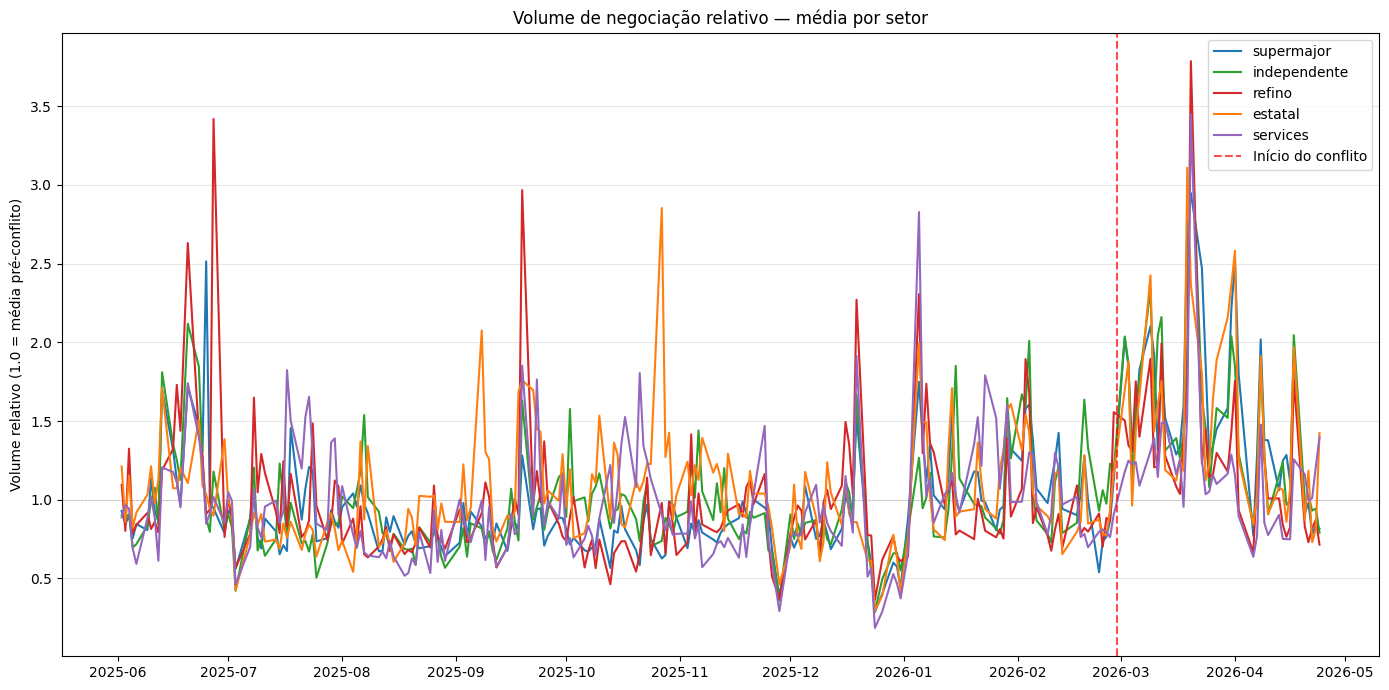

In [24]:
# Volume relativo médio por setor

fig, ax = plt.subplots(figsize=(14, 7))

for cat, cor in cores_setor.items():
    tickers = categorias[cat]
    # Alguns tickers podem não ter volume (ETFs/Brent) — filtrar os disponíveis
    tickers_disp = [t for t in tickers if t in vol_relativo.columns]
    if not tickers_disp:
        continue
    media_vol = vol_relativo[tickers_disp].mean(axis=1)
    ax.plot(media_vol, color=cor, linewidth=1.5, label=cat)

add_evento(ax)
ax.axhline(1.0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_ylabel('Volume relativo (1.0 = média pré-conflito)')
ax.set_title('Volume de negociação relativo — média por setor')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

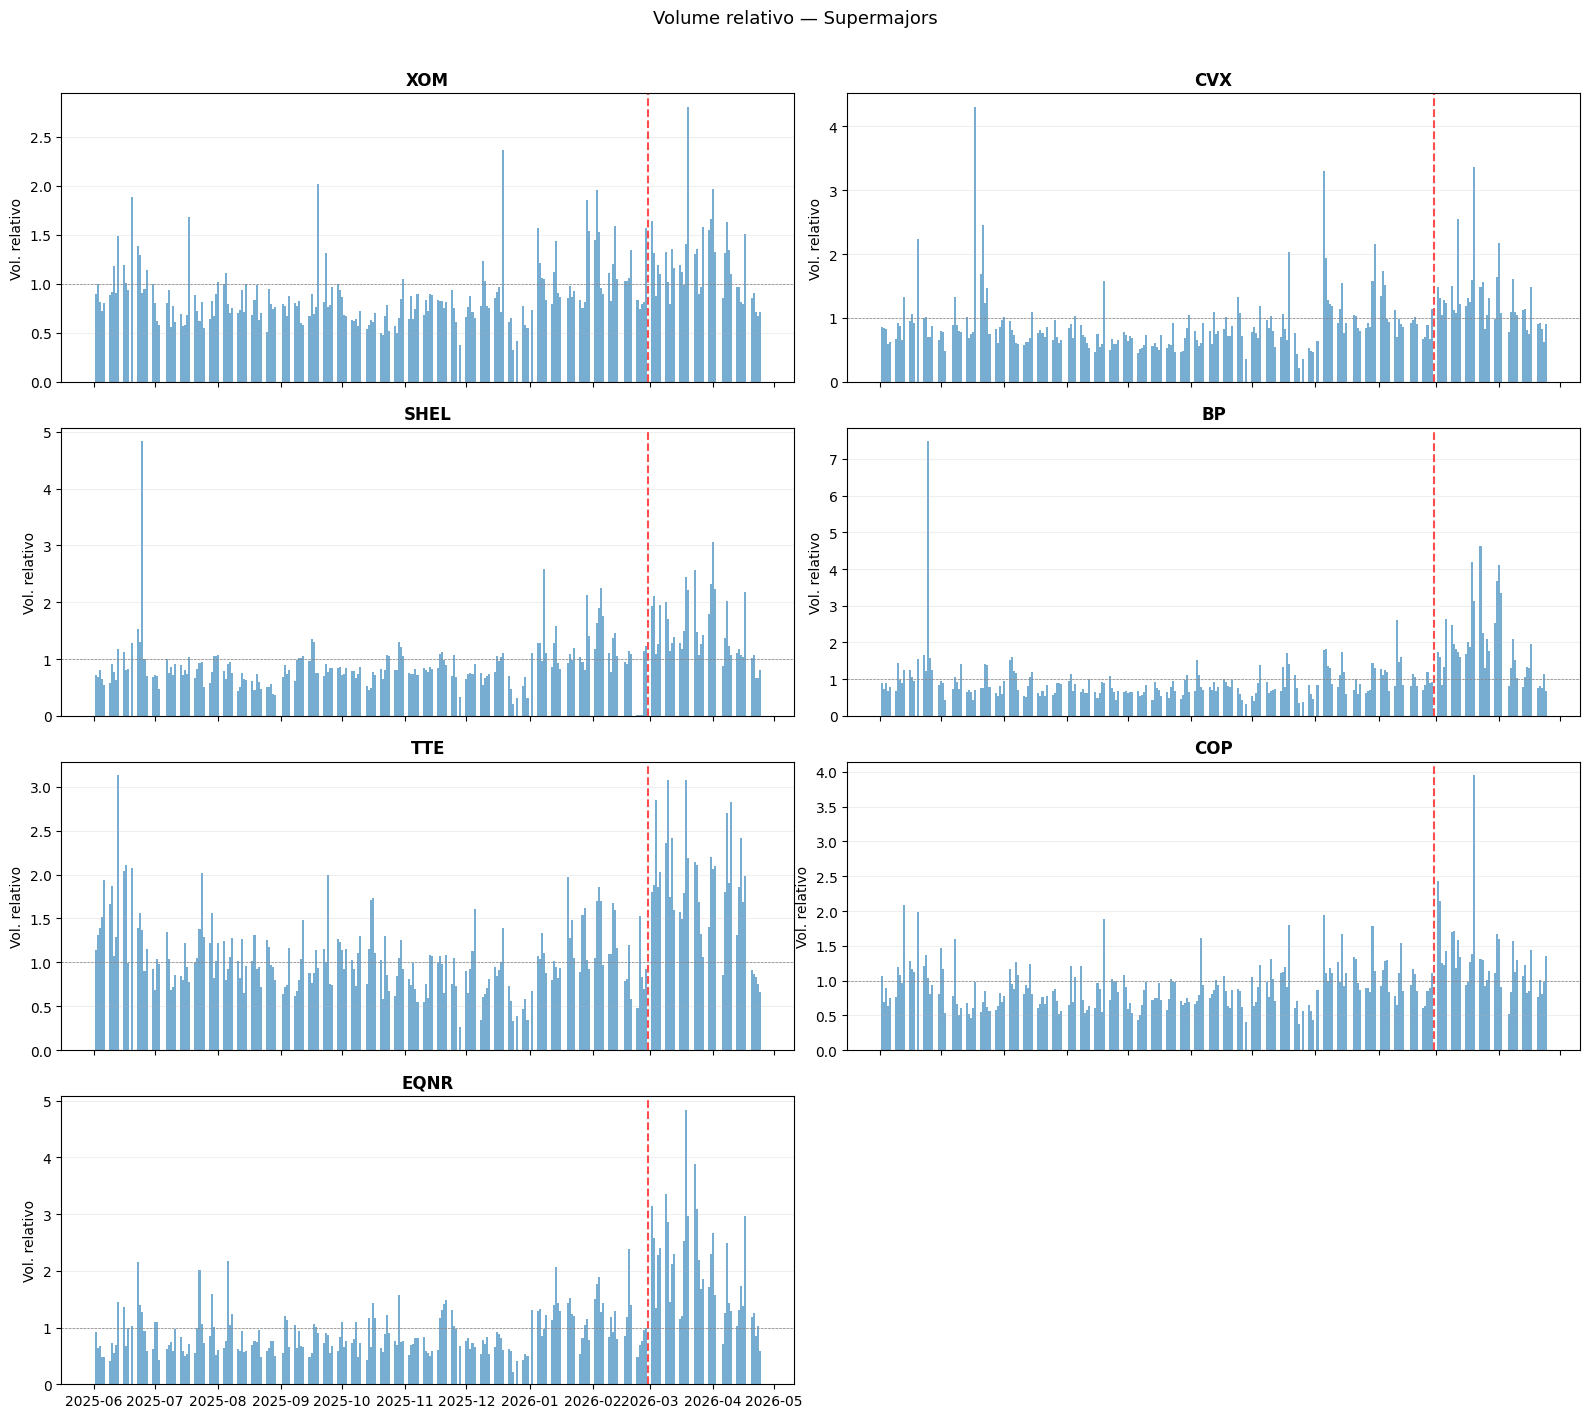

In [25]:
# Volume individual — Supermajors

n_rows = (len(supermajors) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 3.5 * n_rows), sharex=True)
axes = axes.flatten()

for ax, ticker in zip(axes, supermajors):
    if ticker in vol_relativo.columns:
        ax.bar(vol_relativo.index, vol_relativo[ticker], width=1, alpha=0.6)
        add_evento(ax, label=None)
        ax.axhline(1.0, color='gray', linewidth=0.5, linestyle='--')
        ax.set_title(ticker, fontweight='bold')
        ax.set_ylabel('Vol. relativo')
        ax.grid(axis='y', alpha=0.2)

for j in range(len(supermajors), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Volume relativo — Supermajors', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Drawdown

O drawdown mede a queda percentual em relação ao pico anterior. É uma medida de risco que mostra o pior cenário para quem comprou no ponto mais alto. A expectativa é ver drawdowns significativos em refinarias e drawdowns menores (ou picos menores) em produtoras no período pós-conflito.

In [26]:
def calcular_drawdown(log_retornos):
    """Calcula drawdown a partir de log-retornos."""
    cum = np.exp(log_retornos.cumsum())  # correto para log-retornos
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd

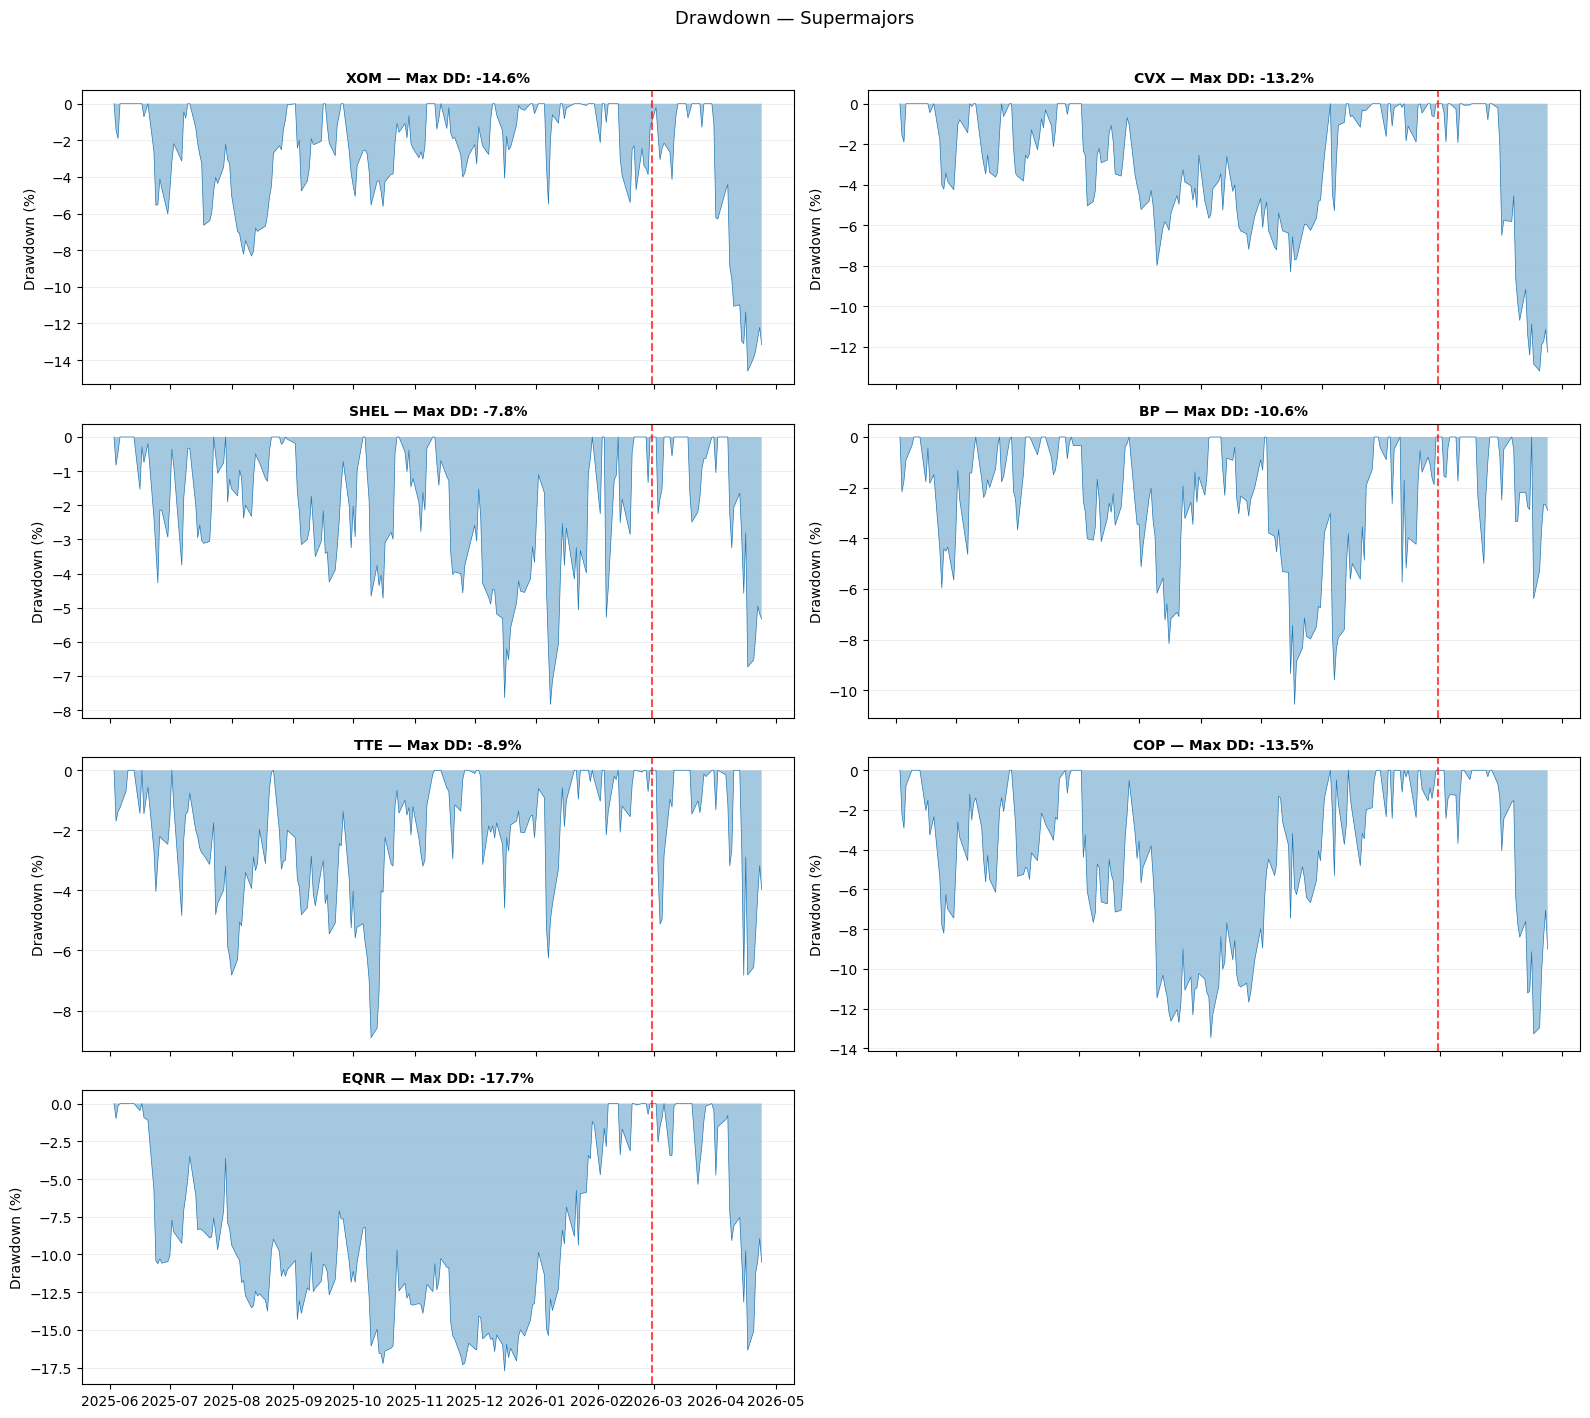

In [27]:
# Drawdown — Supermajors

n_rows = (len(supermajors) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 3.5 * n_rows), sharex=True)
axes = axes.flatten()

for ax, ticker in zip(axes, supermajors):
    dd = calcular_drawdown(log_ret[ticker])
    ax.fill_between(dd.index, dd.values * 100, 0, alpha=0.4)
    ax.plot(dd.index, dd.values * 100, linewidth=0.5)
    add_evento(ax, label=None)
    ax.set_title(f'{ticker} — Max DD: {dd.min()*100:.1f}%', fontsize=10, fontweight='bold')
    ax.set_ylabel('Drawdown (%)')
    ax.grid(axis='y', alpha=0.2)

for j in range(len(supermajors), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Drawdown — Supermajors', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

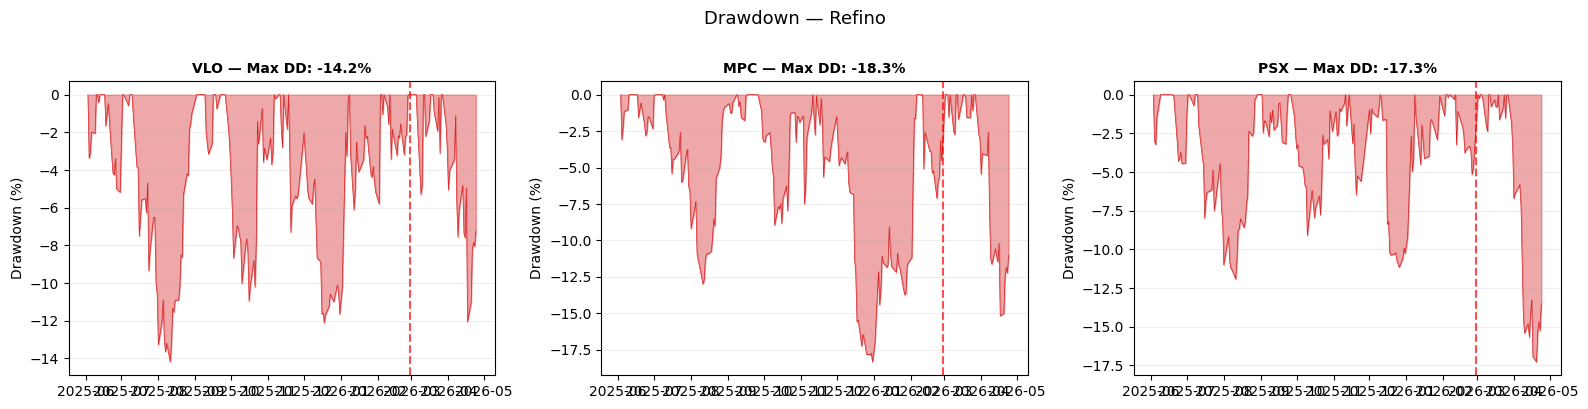

In [28]:
# Drawdown — Refino

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for ax, ticker in zip(axes, refino):
    dd = calcular_drawdown(log_ret[ticker])
    ax.fill_between(dd.index, dd.values * 100, 0, alpha=0.4, color='#d62728')
    ax.plot(dd.index, dd.values * 100, linewidth=0.5, color='#d62728')
    add_evento(ax, label=None)
    ax.set_title(f'{ticker} — Max DD: {dd.min()*100:.1f}%', fontsize=10, fontweight='bold')
    ax.set_ylabel('Drawdown (%)')
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Drawdown — Refino', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 6.1 Drawdown médio por setor — comparação direta

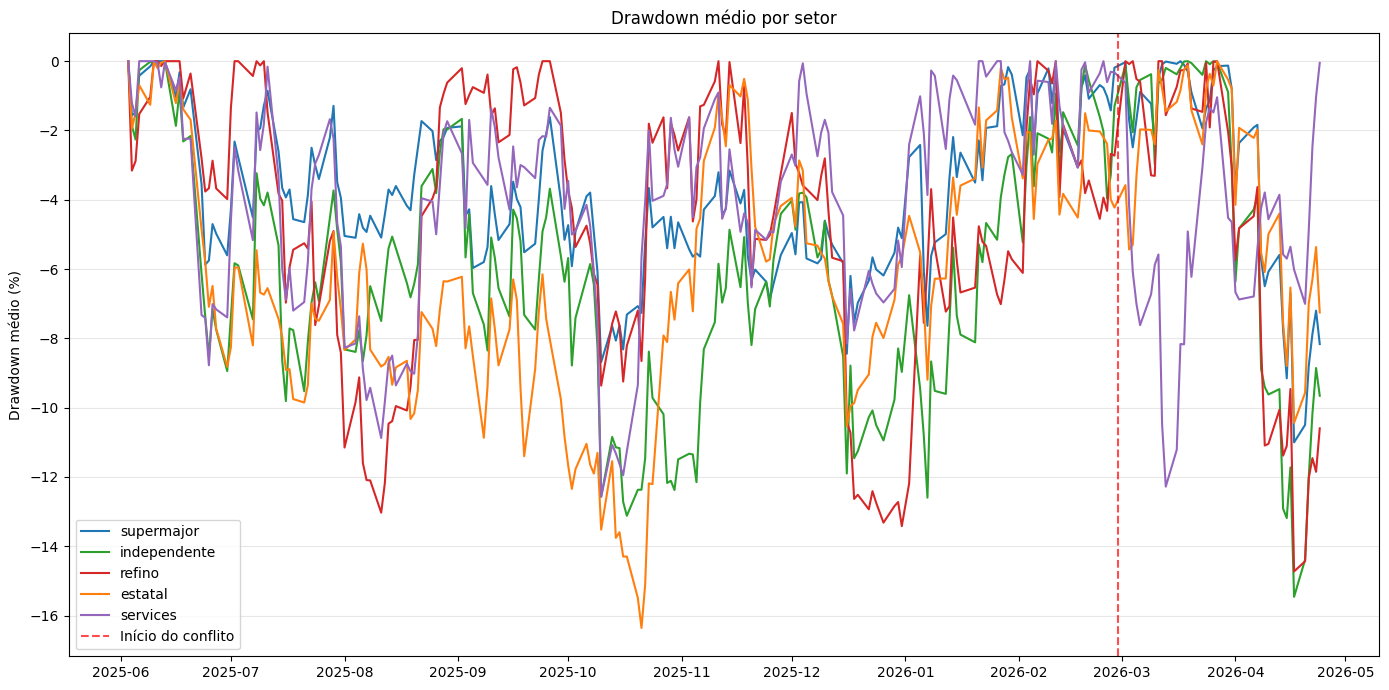

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))

for cat, cor in cores_setor.items():
    tickers = categorias[cat]
    tickers_disp = [t for t in tickers if t in log_ret.columns]
    dd_setor = pd.DataFrame({t: calcular_drawdown(log_ret[t]) for t in tickers_disp})
    dd_media = dd_setor.mean(axis=1) * 100
    ax.plot(dd_media, color=cor, linewidth=1.5, label=cat)

add_evento(ax)
ax.set_ylabel('Drawdown médio (%)')
ax.set_title('Drawdown médio por setor')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

É possível ver novos vales em todos os setores depois do início do conflito. Isso indica que em algum momento próximo ao conflito as ações dessas empresas alcaçaram um pico.

---
## 7. Hipóteses testáveis nos dados

### 7.1 Produtoras vs. Refinarias: quem ganhou e quem perdeu?

A hipótese é que produtoras de petróleo se beneficiam com preços mais altos (vendem um produto mais caro), enquanto refinarias sofrem (compram insumo mais caro sem necessariamente repassar). Comparamos o retorno acumulado médio de cada grupo no período pré e pós-conflito.

In [30]:
# Retorno acumulado pós-conflito por setor

ret_pos = log_ret.loc[EVENTO:]

print('Retorno acumulado (%) desde 28/02/2026 — média por setor:\n')
for cat, tickers in categorias.items():
    tickers_disp = [t for t in tickers if t in ret_pos.columns]
    if not tickers_disp:
        continue
    ret_acum = (np.exp(ret_pos[tickers_disp].sum()) - 1) * 100
    print(f'{cat:15s}: {ret_acum.mean():.1f}% (individual: {dict(ret_acum.round(1))})')

Retorno acumulado (%) desde 28/02/2026 — média por setor:

supermajor     : 10.0% (individual: {'XOM': np.float64(-2.4), 'CVX': np.float64(-0.8), 'SHEL': np.float64(6.7), 'BP': np.float64(19.0), 'TTE': np.float64(12.9), 'COP': np.float64(7.3), 'EQNR': np.float64(27.2)})
independente   : 12.5% (individual: {'OXY': np.float64(8.1), 'DVN': np.float64(10.7), 'FANG': np.float64(12.6), 'EOG': np.float64(8.1), 'APA': np.float64(25.1), 'CTRA': np.float64(10.4)})
services       : 9.2% (individual: {'SLB': np.float64(9.4), 'HAL': np.float64(12.7), 'BKR': np.float64(5.6)})
refino         : 11.3% (individual: {'VLO': np.float64(15.3), 'MPC': np.float64(13.1), 'PSX': np.float64(5.5)})
estatal        : 15.9% (individual: {'PBR': np.float64(26.2), 'SU': np.float64(14.1), 'CNQ': np.float64(2.0), 'EC': np.float64(16.1), 'YPF': np.float64(21.3)})
etf            : 31.3% (individual: {'XLE': np.float64(2.4), 'OIH': np.float64(10.1), 'USO': np.float64(61.6), 'BNO': np.float64(51.1)})


No período pós início do conflito, quem mais ganhou, em média, foram os fundos e, em segundo lugar, as estatais. Supermajors, refinarias e produtoras independentes, ficaram praticamente no mesmo nível de retorno, entre 10 e 12,5%. O que contradiz a teoria de que produtoras deveriam estar ganhando mais do que refinarias (mais especificamente, refinarias ganahram em média 1,3% a mais do que supermajors)

### 7.2 Estatais vs. privadas: quem repassa mais o preço do petróleo?

Empresas estatais podem ter políticas de preços administradas (como a Petrobras historicamente), o que faria com que o aumento do preço internacional fosse menos refletido no valor das suas ações. Comparamos a sensibilidade ao Brent.

In [31]:
# Correlação de cada setor com o Brent

ret_brent = log_ret['BZ=F'] if 'BZ=F' in log_ret.columns else None

if ret_brent is not None:
    print('Correlação dos retornos com o Brent — média por setor:\n')
    for cat, tickers in categorias.items():
        tickers_disp = [t for t in tickers if t in log_ret.columns]
        if not tickers_disp:
            continue
        corrs = log_ret[tickers_disp].corrwith(ret_brent)
        print(f'{cat:15s}: {corrs.mean():.3f} (individual: {dict(corrs.round(3))})')
else:
    print('Brent não disponível nos dados')

Correlação dos retornos com o Brent — média por setor:

supermajor     : 0.541 (individual: {'XOM': np.float64(0.595), 'CVX': np.float64(0.541), 'SHEL': np.float64(0.46), 'BP': np.float64(0.543), 'TTE': np.float64(0.402), 'COP': np.float64(0.587), 'EQNR': np.float64(0.657)})
independente   : 0.549 (individual: {'OXY': np.float64(0.591), 'DVN': np.float64(0.535), 'FANG': np.float64(0.574), 'EOG': np.float64(0.572), 'APA': np.float64(0.547), 'CTRA': np.float64(0.475)})
services       : 0.165 (individual: {'SLB': np.float64(0.068), 'HAL': np.float64(0.321), 'BKR': np.float64(0.106)})
refino         : 0.408 (individual: {'VLO': np.float64(0.405), 'MPC': np.float64(0.418), 'PSX': np.float64(0.4)})
estatal        : 0.454 (individual: {'PBR': np.float64(0.455), 'SU': np.float64(0.524), 'CNQ': np.float64(0.599), 'EC': np.float64(0.462), 'YPF': np.float64(0.229)})
etf            : 0.616 (individual: {'XLE': np.float64(0.579), 'OIH': np.float64(0.245), 'USO': np.float64(0.809), 'BNO': np.float64

O preço do petróleo brent, na média, afeta menos as estatais do que produtoras supermajors e independentes, o que era esperado, visto que existem outras variáveis, como risco político, que podem influenciar uma empresa estatal. No entanto, chama atenção que o preço de ações de refinarias são ainda menos sensíveis em relação ao preço do petróleo brent. Pensando em algumas explicações para isso, tem-se o repasse do preço, se a demanda por derivados de petróleo for inelástica no curto prazo, os produtos vendidos pela refinaria podem ficar ainda mais caros em relação ao preço do petroleo brent. Outra questão é que todas as refinarias apresentadas nessa análise são americanas, e os EUA são o maior produtor de petróleo do mundo, e, além disso, a guerra no Oriente Médio e o fechamento do Estreito de Ormuz afeta principalmente a Ásia e a Europa, o que pode ter até contribuído para o bom desempenho dessas empresas. Uma terceira explicação é o mercado ter precificado erroneamente as consequências e tempo de duração desse conflito.

### 7.3 Volume e nacionalidade: insider trading?

Uma hipótese especulativa: empresas americanas teriam volume de negociação anormalmente alto antes de eventos relacionados ao conflito (sugerindo possível insider trading). Verificamos o volume relativo médio por nacionalidade.

**Nota:** essa análise é exploratória e não constitui evidência de insider trading. Diferenças de volume podem ser explicadas por liquidez, fuso horário e outros fatores.

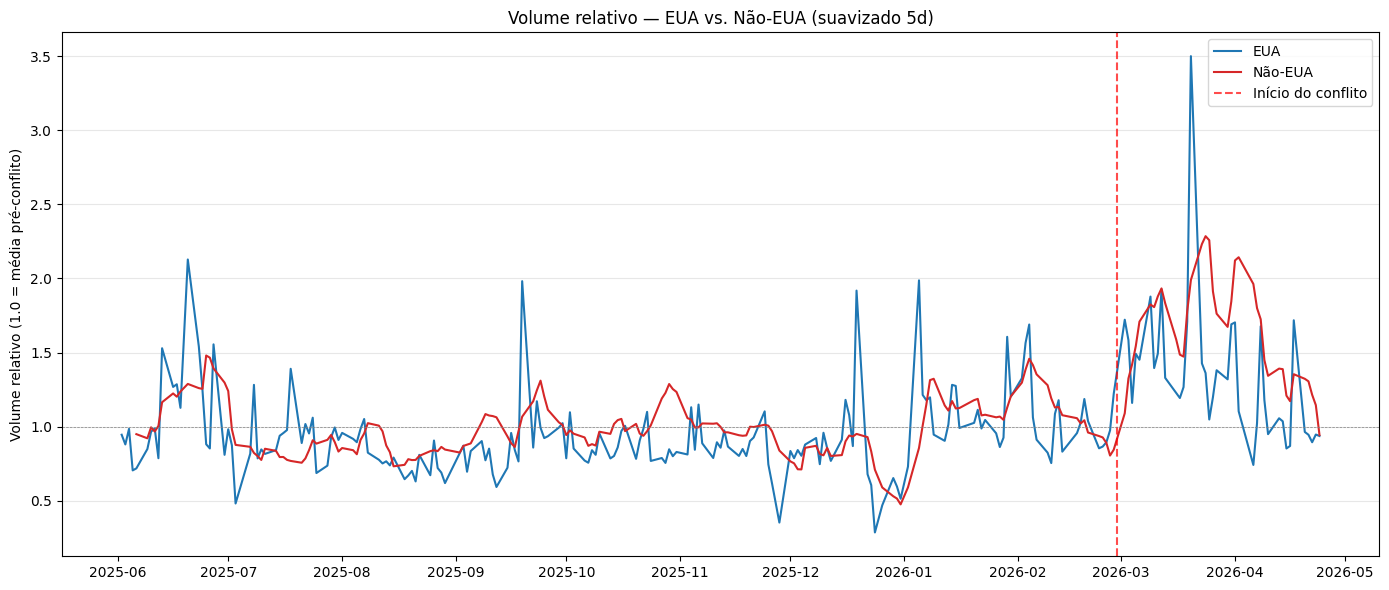

In [32]:
# Classificação por nacionalidade

eua_tickers = ['XOM', 'CVX', 'COP', 'OXY', 'DVN', 'FANG', 'EOG', 'MRO',
               'APA', 'CTRA', 'HES', 'SLB', 'HAL', 'BKR', 'VLO', 'MPC', 'PSX']

non_eua_tickers = ['SHEL', 'BP', 'TTE', 'EQNR', 'PBR', 'SU', 'CNQ', 'EC', 'YPF']

eua_disp = [t for t in eua_tickers if t in vol_relativo.columns]
non_eua_disp = [t for t in non_eua_tickers if t in vol_relativo.columns]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(vol_relativo[eua_disp].mean(axis=1),
        label='EUA', linewidth=1.5, color='#1f77b4')
ax.plot(vol_relativo[non_eua_disp].mean(axis=1).rolling(5).mean(),
        label='Não-EUA', linewidth=1.5, color='#d62728')

add_evento(ax)
ax.axhline(1.0, color='gray', linewidth=0.5, linestyle='--')
ax.set_ylabel('Volume relativo (1.0 = média pré-conflito)')
ax.set_title('Volume relativo — EUA vs. Não-EUA (suavizado 5d)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Frente as várias notícas de insider trading nos EUA, observei o volume de ações de petrolíferas e refinarias de dentro e fora dos Estados unidos tentando ver se os dados apontariam algum volume estranhamente elevado anter do conflito (era esperado que não, pois, se tiver ocorrido insider trading, provavelmente o volume não foi grande o suficiente para ser refletidos nos dados agregados).

---
## Resumo das estatísticas por setor

In [33]:
# Tabela resumo: retorno total, volatilidade média, max drawdown — por setor

resumo = []

for cat, tickers in categorias.items():
    tickers_disp = [t for t in tickers if t in log_ret.columns]
    if not tickers_disp:
        continue
    
    ret_total = (np.exp(log_ret[tickers_disp].sum()) - 1).mean() * 100
    vol_media = log_ret[tickers_disp].std().mean() * np.sqrt(252) * 100  # anualizada
    
    dd_medio = pd.DataFrame(
        {t: calcular_drawdown(log_ret[t]) for t in tickers_disp}
    ).min().mean() * 100
    
    resumo.append({
        'Setor': cat,
        'Retorno total (%)': round(ret_total, 1),
        'Volatilidade anualizada (%)': round(vol_media, 1),
        'Max Drawdown médio (%)': round(dd_medio, 1),
    })

df_resumo = pd.DataFrame(resumo).set_index('Setor')
df_resumo

,Retorno total (%),Volatilidade anualizada (%),Max Drawdown médio (%)
Setor,,,
supermajor,49.6,25.6,-12.3
independente,55.1,32.7,-16.6
services,89.4,34.4,-14.8
refino,59.1,31.3,-16.6
estatal,60.2,34.0,-18.1
etf,80.7,33.1,-15.0
